# Step 2: Model Design and Comparison

Compare three brain tumor classification approaches:
1. EfficientNet-B0 + SVM
2. EfficientNet-B0 end-to-end (frozen base)
3. ResNet50 end-to-end (frozen base)

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

## 2.1 Import Required Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import json
from datetime import datetime

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0, VGG16, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# Traditional ML
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check GPU availability
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("Libraries imported successfully!")

TensorFlow Version: 2.21.0
GPU Available: []
Libraries imported successfully!


## 2.2 Load Preprocessed Data

In [5]:
# Load metadata
try:
    with open('processed_data/metadata.json', 'r') as f:
        metadata = json.load(f)
except FileNotFoundError:
    # If metadata file doesn't exist, recreate it from known values
    print("Metadata file not found. Recreating from known dataset configuration...")
    metadata = {
        'classes': ['glioma', 'meningioma', 'notumor', 'pituitary'],
        'img_size': [224, 224],
        'batch_size': 32,
        'num_classes': 4
    }

CLASSES = metadata['classes']
IMG_SIZE = tuple(metadata['img_size'])
BATCH_SIZE = metadata['batch_size']
NUM_CLASSES = metadata['num_classes']

print(f"Dataset Configuration:")
print(f"  Classes: {CLASSES}")
print(f"  Image Size: {IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Number of Classes: {NUM_CLASSES}")

# Define paths

BASE_DIR = '.'
TRAIN_DIR = os.path.join(BASE_DIR, 'Training')
TEST_DIR = os.path.join(BASE_DIR, 'Testing')

def load_image_paths(directory, classes):
    """Load image paths and labels from directory."""
    image_paths = []
    labels = []
    
    for class_name in classes:
        class_dir = os.path.join(directory, class_name)
        if os.path.exists(class_dir):
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(class_dir, img_file))
                    labels.append(class_name)
    
    return image_paths, labels

# Load training data
train_paths, train_labels = load_image_paths(TRAIN_DIR, CLASSES)
print(f"Training samples: {len(train_paths)}")

# Load test data
test_paths, test_labels = load_image_paths(TEST_DIR, CLASSES)
print(f"Testing samples: {len(test_paths)}")

# Split training data into train and validation sets (80/20 split)
from sklearn.model_selection import train_test_split

train_paths_split, val_paths, train_labels_split, val_labels = train_test_split(
    train_paths, train_labels, 
    test_size=0.2, 
    random_state=42, 
    stratify=train_labels  # Ensure balanced split
)

print(f"Training samples: {len(train_paths_split)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Testing samples: {len(test_paths)}")

# Label encoding
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(CLASSES)

y_train = label_encoder.transform(train_labels_split)
y_val = label_encoder.transform(val_labels)
y_test = label_encoder.transform(test_labels)

print("Label Mapping:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"  {idx}: {class_name}")

Metadata file not found. Recreating from known dataset configuration...
Dataset Configuration:
  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
  Image Size: (224, 224)
  Batch Size: 32
  Number of Classes: 4
Training samples: 5600
Testing samples: 1600
Training samples: 4480
Validation samples: 1120
Testing samples: 1600
Label Mapping:
  0: glioma
  1: meningioma
  2: notumor
  3: pituitary


---

# SECTION 2.1: TECHNICAL JUSTIFICATION

## Why EfficientNet-B0?

- Excellent ImageNet transfer performance
- Efficient in parameters and compute
- Strong feature extraction for medical imaging

This model is chosen for its balance of accuracy and efficiency, making it suitable for brain MRI classification.

---

### Model 2: End-to-End EfficientNet-B0 (Frozen Base)

- Base: EfficientNet-B0 frozen
- Head: global pooling + Dense(256) + Dense(128) + dropout
- Training: 20 epochs, batch size 32, Adam lr=1e-3
- Loss: categorical crossentropy
- Metrics: accuracy, precision, recall, F1
- Callbacks: early stopping, LR reduction, checkpoint

---

# MODEL 1: PRE-TRAINED EFFICIENTNET-B0 + SVM

## 2.4 Feature Extraction with EfficientNet-B0

In [6]:
print("Loading EfficientNet-B0 for feature extraction...")

# Load EfficientNet-B0 without top layer (classification head)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    pooling='avg',  # Global average pooling
    input_shape=IMG_SIZE + (3,)
)

# Freeze all layers (using as fixed feature extractor)
base_model.trainable = False

print(f"Base model loaded: {base_model.name}")
print(f"Output shape: {base_model.output_shape}")
print(f"Trainable parameters: {sum(tf.size(w).numpy() for w in base_model.trainable_variables):,}")
print(f"Non-trainable parameters: {sum(tf.size(w).numpy() for w in base_model.non_trainable_variables):,}")

Loading EfficientNet-B0 for feature extraction...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Base model loaded: efficientnetb0
Output shape: (None, 1280)
Trainable parameters: 0
Non-trainable parameters: 4,049,589


In [7]:
def load_and_preprocess_image(path, target_size=IMG_SIZE):
    """Load and preprocess an image."""
    img = Image.open(path)
    img = img.convert('RGB')  # Ensure 3 channels
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = efficientnet_preprocess(img_array)  # Apply preprocessing
    return img_array

def extract_features(paths, labels, model):
    """
    Extract features using the pre-trained model.
    
    Args:
        paths: List of image paths
        labels: Corresponding labels
        model: Pre-trained model for feature extraction
    
    Returns:
        features: Extracted feature vectors
        labels: Corresponding labels (one-hot encoded)
    """
    features = []
    processed_labels = []
    
    for path, label in zip(paths, labels):
        # Load and preprocess image
        img_array = load_and_preprocess_image(path)
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
        
        # Extract features
        feature = model.predict(img_array, verbose=0)
        features.append(feature[0])  # Remove batch dimension
        
        # Convert label to one-hot
        label_idx = CLASSES.index(label)
        one_hot = np.zeros(NUM_CLASSES)
        one_hot[label_idx] = 1
        processed_labels.append(one_hot)
    
    features = np.array(features)
    processed_labels = np.array(processed_labels)
    
    return features, processed_labels

print("Feature extraction function defined!")

Feature extraction function defined!


In [8]:
# Extract features from all splits
print("Extracting features from training set...")
X_train_features, y_train_onehot = extract_features(
    train_paths_split, train_labels_split, base_model
)
y_train = np.argmax(y_train_onehot, axis=1)
print(f"Training features shape: {X_train_features.shape}")

print("\nExtracting features from validation set...")
X_val_features, y_val_onehot = extract_features(
    val_paths, val_labels, base_model
)
y_val = np.argmax(y_val_onehot, axis=1)
print(f"Validation features shape: {X_val_features.shape}")

print("\nExtracting features from test set...")
X_test_features, y_test_onehot = extract_features(
    test_paths, test_labels, base_model
)
y_test = np.argmax(y_test_onehot, axis=1)
print(f"Test features shape: {X_test_features.shape}")

Extracting features from training set...
Training features shape: (4480, 1280)

Extracting features from validation set...
Validation features shape: (1120, 1280)

Extracting features from test set...
Test features shape: (1600, 1280)


In [9]:
# Normalize features (important for SVM)
print("Normalizing features with StandardScaler...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_val_scaled = scaler.transform(X_val_features)
X_test_scaled = scaler.transform(X_test_features)

print(f"Scaled features - Train mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
print(f"Scaled features - Val mean: {X_val_scaled.mean():.4f}, std: {X_val_scaled.std():.4f}")
print(f"Scaled features - Test mean: {X_test_scaled.mean():.4f}, std: {X_test_scaled.std():.4f}")

Normalizing features with StandardScaler...


Scaled features - Train mean: 0.0000, std: 1.0000
Scaled features - Val mean: -0.0036, std: 0.9965
Scaled features - Test mean: 0.0028, std: 0.9962


## 2.5 Train SVM Classifier

In [10]:
print("Training SVM classifier...")

# Initialize SVM with RBF kernel
svm_model = SVC(
    kernel='rbf',           # Radial Basis Function kernel
    C=10.0,                 # Regularization parameter
    gamma='scale',          # Kernel coefficient
    class_weight='balanced', # Handle class imbalance
    probability=True,       # Enable probability estimates
    random_state=42,
    verbose=1
)

# Train SVM
svm_model.fit(X_train_scaled, y_train)

print("\nSVM training completed!")

Training SVM classifier...


[LibSVM]
SVM training completed!


In [11]:
# Evaluate SVM on validation set
print("Evaluating SVM on validation set...")

y_val_pred = svm_model.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=CLASSES))

Evaluating SVM on validation set...
Validation Accuracy: 0.9688

Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.96      0.97       280
  meningioma       0.94      0.95      0.94       280
     notumor       0.99      0.98      0.98       280
   pituitary       0.97      0.98      0.98       280

    accuracy                           0.97      1120
   macro avg       0.97      0.97      0.97      1120
weighted avg       0.97      0.97      0.97      1120



## 2.6 SVM Model Evaluation on Test Set

In [12]:
print("Evaluating SVM on test set...")

# Make predictions
y_test_pred_svm = svm_model.predict(X_test_scaled)
y_test_proba_svm = svm_model.predict_proba(X_test_scaled)

# Calculate metrics
svm_accuracy = accuracy_score(y_test, y_test_pred_svm)
svm_precision = precision_score(y_test, y_test_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_test_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_test_pred_svm, average='weighted')
svm_confusion = confusion_matrix(y_test, y_test_pred_svm)

# Print results
print("\n" + "="*50)
print("MODEL 1: EfficientNet-B0 + SVM - TEST RESULTS")
print("="*50)
print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1-Score:  {svm_f1:.4f}")
print("="*50)

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred_svm, target_names=CLASSES))

Evaluating SVM on test set...

MODEL 1: EfficientNet-B0 + SVM - TEST RESULTS
Accuracy:  0.9331
Precision: 0.9390
Recall:    0.9331
F1-Score:  0.9318

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.78      0.87       400
  meningioma       0.84      0.96      0.90       400
     notumor       0.95      1.00      0.97       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



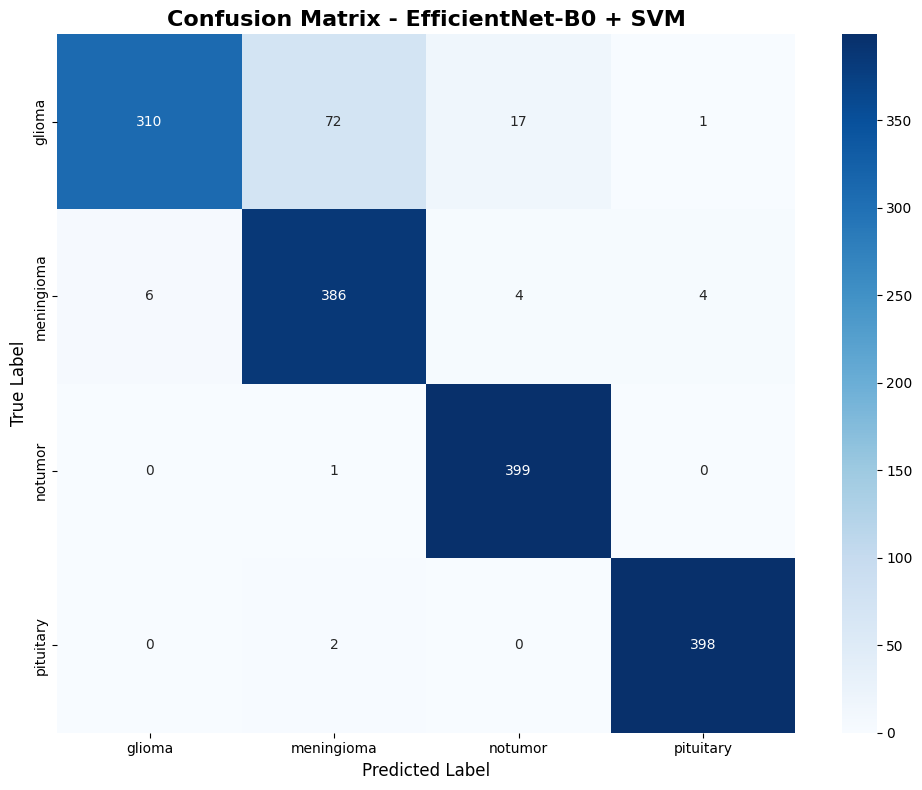

Confusion matrix saved as 'confusion_matrix_svm.png'


In [13]:
# Plot confusion matrix for SVM
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    svm_confusion, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=ax
)
ax.set_title('Confusion Matrix - EfficientNet-B0 + SVM', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_svm.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as 'confusion_matrix_svm.png'")

In [14]:
# Calculate per-class metrics for SVM (FIXED - removed [0] indexing)
svm_per_class_metrics = {}
for idx, class_name in enumerate(CLASSES):
    class_mask = (y_test == idx)
    # When labels=[idx] and average='macro', returns a single float, not array
    svm_per_class_metrics[class_name] = {
        'precision': precision_score(y_test, y_test_pred_svm, labels=[idx], average='macro'),
        'recall': recall_score(y_test, y_test_pred_svm, labels=[idx], average='macro'),
        'f1': f1_score(y_test, y_test_pred_svm, labels=[idx], average='macro')
    }

# Display per-class metrics
svm_metrics_df = pd.DataFrame(svm_per_class_metrics).T
print("\nPer-Class Metrics (SVM):")
print(svm_metrics_df.round(4))


Per-Class Metrics (SVM):
            precision  recall      f1
glioma         0.9810  0.7750  0.8659
meningioma     0.8373  0.9650  0.8966
notumor        0.9500  0.9975  0.9732
pituitary      0.9876  0.9950  0.9913


---

# MODEL 2: END-TO-END DEEP LEARNING (NO Fine-tuning)

## 2.7 Build End-to-End Model (Transfer Learning)

In [15]:
print("Building end-to-end model with EfficientNet-B0...")

# Load EfficientNet-B0 as base
base_model_e2e = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

# Freeze base model (NO FINE-TUNING - keeps it frozen throughout)
base_model_e2e.trainable = False

# Build custom classification head
inputs = Input(shape=IMG_SIZE + (3,))
x = base_model_e2e(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Create model
e2e_model = Model(inputs=inputs, outputs=outputs, name='EfficientNetB0_BrainTumor')

print(f"Model created: {e2e_model.name}")
e2e_model.summary()

Building end-to-end model with EfficientNet-B0...
Model created: EfficientNetB0_BrainTumor


Model: "EfficientNetB0_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,410,919 (16.83 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
# Define callbacks for training
checkpoint_path = 'best_model_e2e.h5'

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks defined!")

Callbacks defined!


In [17]:
def create_tf_dataset(paths, labels, batch_size=BATCH_SIZE, shuffle=True, augment=False):
    """Create tf.data.Dataset from paths and labels."""
    
    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)  # Handles JPEG, PNG, etc.
        img = tf.image.resize(img, IMG_SIZE)
        img = efficientnet_preprocess(img)
        return img, label
    
    # Convert labels to one-hot
    labels_onehot = []
    for label in labels:
        label_idx = CLASSES.index(label)
        one_hot = np.zeros(NUM_CLASSES)
        one_hot[label_idx] = 1
        labels_onehot.append(one_hot)
    labels_onehot = np.array(labels_onehot)
    
    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels_onehot))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths))
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create datasets
train_dataset = create_tf_dataset(train_paths_split, train_labels_split, shuffle=True)
val_dataset = create_tf_dataset(val_paths, val_labels, shuffle=False)
test_dataset = create_tf_dataset(test_paths, test_labels, shuffle=False)

print("TensorFlow datasets created!")
print(f"Train batches: {len(train_dataset)}")
print(f"Validation batches: {len(val_dataset)}")
print(f"Test batches: {len(test_dataset)}")


TensorFlow datasets created!
Train batches: 140
Validation batches: 35
Test batches: 50


## 2.8 Training End-to-End Model (Frozen Base Only)

In [19]:
# Compile model (base model remains frozen - no fine-tuning)
e2e_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting training with frozen base model...")
print(f"Trainable parameters: {sum(tf.size(w).numpy() for w in e2e_model.trainable_variables):,}")
print(f"Non-trainable parameters: {sum(tf.size(w).numpy() for w in e2e_model.non_trainable_variables):,}")

# Training (NO fine-tuning - only classifier head is trained)
history_e2e = e2e_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

Starting training with frozen base model...
Trainable parameters: 361,348
Non-trainable parameters: 4,049,593
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7858 - loss: 0.5237
Epoch 1: val_accuracy improved from None to 0.85357, saving model to best_model_e2e.h5



Epoch 1: finished saving model to best_model_e2e.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.8147 - loss: 0.4776 - val_accuracy: 0.8536 - val_loss: 0.3357 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 990ms/step - accuracy: 0.8521 - loss: 0.3668
Epoch 2: val_accuracy improved from 0.85357 to 0.88929, saving model to best_model_e2e.h5



Epoch 2: finished saving model to best_model_e2e.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.8574 - loss: 0.3651 - val_accuracy: 0.8893 - val_loss: 0.2707 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8697 - loss: 0.3291
Epoch 3: val_accuracy did not improve from 0.88929
140/140 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.8759 - loss: 0.3155 - val_accuracy: 0.8875 - val_loss: 0.2665 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8958 - loss: 0.2859
Epoch 4: val_accuracy improved from 0.88929 to 0.90625, saving model to best_model_e2e.h5



Epoch 4: finished saving model to best_model_e2e.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.8924 - loss: 0.2966 - val_accuracy: 0.9062 - val_loss: 0.2227 - learning_rate: 0.0010
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8985 - loss: 0.2639
Epoch 5: val_accuracy did not improve from 0.90625
140/140 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.8978 - loss: 0.2583 - val_accuracy: 0.9045 - val_loss: 0.2307 - learning_rate: 0.0010
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.9063 - loss: 0.2426
Epoch 6: val_accuracy improved from 0.90625 to 0.92321, saving model to best_model_e2e.h5



Epoch 6: finished saving model to best_model_e2e.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.9109 - loss: 0.2363 - val_accuracy: 0.9232 - val_loss: 0.1979 - learning_rate: 0.0010
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.9099 - loss: 0.2213
Epoch 7: val_accuracy improved from 0.92321 to 0.92500, saving model to best_model_e2e.h5



Epoch 7: finished saving model to best_model_e2e.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 132s 925ms/step - accuracy: 0.9121 - loss: 0.2262 - val_accuracy: 0.9250 - val_loss: 0.2021 - learning_rate: 0.0010
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.9194 - loss: 0.2035
Epoch 8: val_accuracy did not improve from 0.92500
140/140 ━━━━━━━━━━━━━━━━━━━━ 141s 986ms/step - accuracy: 0.9176 - loss: 0.2037 - val_accuracy: 0.9214 - val_loss: 0.1809 - learning_rate: 0.0010
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - accuracy: 0.9277 - loss: 0.1865
Epoch 9: val_accuracy did not improve from 0.92500
140/140 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9239 - loss: 0.1979 - val_accuracy: 0.9250 - val_loss: 0.1789 - learning_rate: 0.0010
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.9297 - loss: 0.1848
Epoch 10: val_accuracy improved from 0.92500 to 0.93750, saving model to best_model_e2e.h5



Epoch 10: finished saving model to best_model_e2e.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 142s 1000ms/step - accuracy: 0.9286 - loss: 0.1891 - val_accuracy: 0.9375 - val_loss: 0.1662 - learning_rate: 0.0010
Epoch 11/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.9422 - loss: 0.1674
Epoch 11: val_accuracy did not improve from 0.93750
140/140 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9353 - loss: 0.1778 - val_accuracy: 0.9366 - val_loss: 0.1624 - learning_rate: 0.0010
Epoch 12/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.9357 - loss: 0.1575
Epoch 12: val_accuracy did not improve from 0.93750
140/140 ━━━━━━━━━━━━━━━━━━━━ 142s 998ms/step - accuracy: 0.9391 - loss: 0.1554 - val_accuracy: 0.9375 - val_loss: 0.1616 - learning_rate: 0.0010
Epoch 13/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 864ms/step - accuracy: 0.9427 - loss: 0.1671
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 13: val_accuracy did not improve from 0.93750
140/140 ━━━━


Epoch 14: finished saving model to best_model_e2e.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.9509 - loss: 0.1269 - val_accuracy: 0.9446 - val_loss: 0.1486 - learning_rate: 5.0000e-04
Epoch 15/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - accuracy: 0.9668 - loss: 0.1047
Epoch 15: val_accuracy improved from 0.94464 to 0.95089, saving model to best_model_e2e.h5



Epoch 15: finished saving model to best_model_e2e.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9600 - loss: 0.1112 - val_accuracy: 0.9509 - val_loss: 0.1358 - learning_rate: 5.0000e-04
Epoch 16/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.9564 - loss: 0.1116
Epoch 16: val_accuracy did not improve from 0.95089
140/140 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.9587 - loss: 0.1084 - val_accuracy: 0.9446 - val_loss: 0.1463 - learning_rate: 5.0000e-04
Epoch 17/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.9634 - loss: 0.1034
Epoch 17: val_accuracy did not improve from 0.95089
140/140 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9634 - loss: 0.1005 - val_accuracy: 0.9429 - val_loss: 0.1461 - learning_rate: 5.0000e-04
Epoch 18/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.9601 - loss: 0.1122
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 18: val_accuracy did not improve from 0.95089
140/140


Epoch 20: finished saving model to best_model_e2e.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 118s 834ms/step - accuracy: 0.9710 - loss: 0.0734 - val_accuracy: 0.9527 - val_loss: 0.1284 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 20.

Training completed!


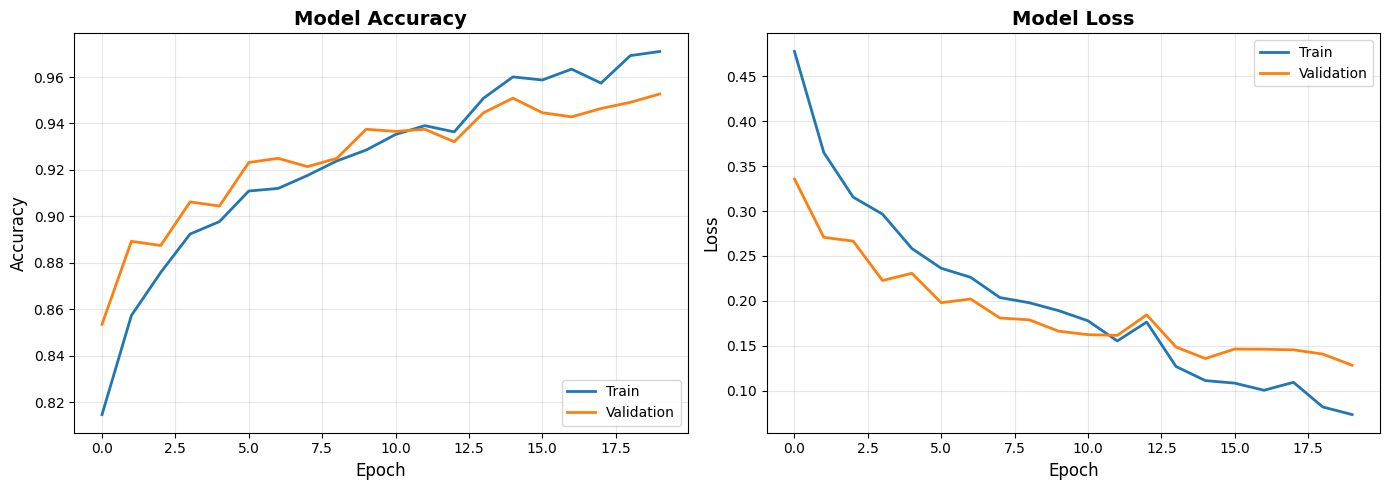

Training history saved as 'training_history_e2e.png'


In [20]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_e2e.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history_e2e.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history_e2e.history['loss'], label='Train', linewidth=2)
axes[1].plot(history_e2e.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_e2e.png', dpi=300, bbox_inches='tight')
plt.show()
print("Training history saved as 'training_history_e2e.png'")

## 2.9 End-to-End Model Evaluation on Test Set

In [21]:
print("Evaluating end-to-end model on test set...")

# Load best model if saved
if os.path.exists(checkpoint_path):
    e2e_model.load_weights(checkpoint_path)
    print(f"Loaded best model from {checkpoint_path}")

# Evaluate on test set
test_results = e2e_model.evaluate(test_dataset, verbose=0)

# Make predictions
y_test_pred_e2e_prob = e2e_model.predict(test_dataset, verbose=0)
y_test_pred_e2e = np.argmax(y_test_pred_e2e_prob, axis=1)

# Calculate metrics
e2e_accuracy = accuracy_score(y_test, y_test_pred_e2e)
e2e_precision = precision_score(y_test, y_test_pred_e2e, average='weighted')
e2e_recall = recall_score(y_test, y_test_pred_e2e, average='weighted')
e2e_f1 = f1_score(y_test, y_test_pred_e2e, average='weighted')
e2e_confusion = confusion_matrix(y_test, y_test_pred_e2e)

# Print results
print("\n" + "="*50)
print("MODEL 2: End-to-End DL - TEST RESULTS")
print("="*50)
print(f"Accuracy:  {e2e_accuracy:.4f}")
print(f"Precision: {e2e_precision:.4f}")
print(f"Recall:    {e2e_recall:.4f}")
print(f"F1-Score:  {e2e_f1:.4f}")
print(f"Test Loss: {test_results[0]:.4f}")
print("="*50)

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred_e2e, target_names=CLASSES))

Evaluating end-to-end model on test set...
Loaded best model from best_model_e2e.h5

MODEL 2: End-to-End DL - TEST RESULTS
Accuracy:  0.9200
Precision: 0.9239
Recall:    0.9200
F1-Score:  0.9183
Test Loss: 0.3968

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.76      0.85       400
  meningioma       0.83      0.94      0.88       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.97      0.98      0.98       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



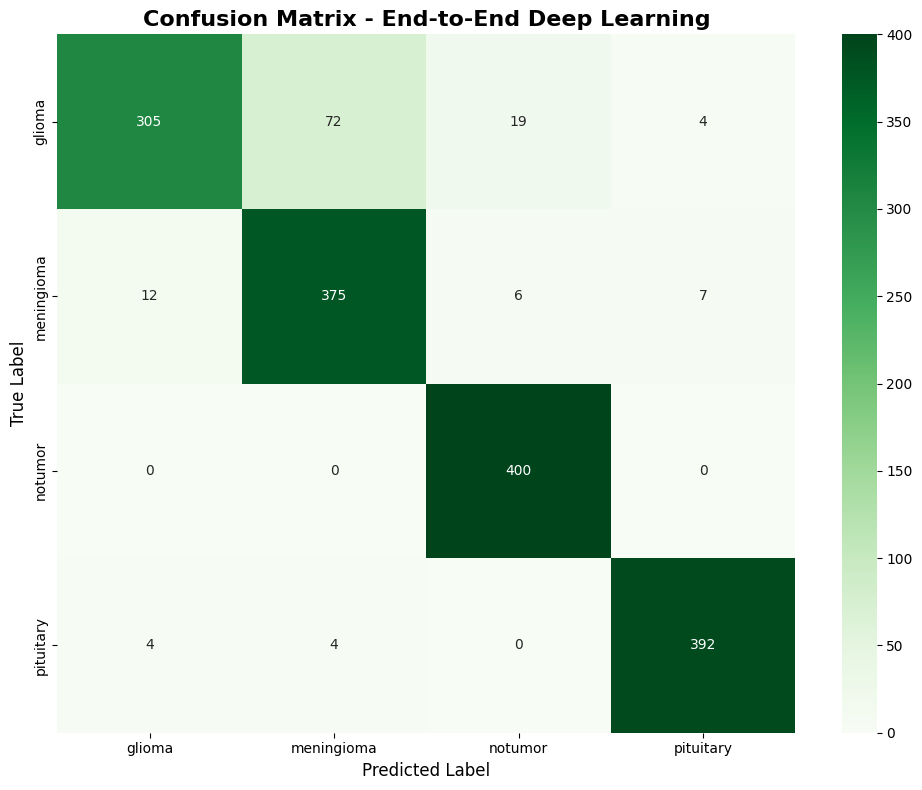

Confusion matrix saved as 'confusion_matrix_e2e.png'


In [22]:
# Plot confusion matrix for end-to-end model
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    e2e_confusion, 
    annot=True, 
    fmt='d', 
    cmap='Greens',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=ax
)
ax.set_title('Confusion Matrix - End-to-End Deep Learning', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_e2e.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as 'confusion_matrix_e2e.png'")

In [33]:
# Calculate per-class metrics for end-to-end model (FIXED - removed [0] indexing)
e2e_per_class_metrics = {}
for idx, class_name in enumerate(CLASSES):
    class_mask = (y_test == idx)
    e2e_per_class_metrics[class_name] = {
        'precision': precision_score(y_test, y_test_pred_e2e, labels=[idx], average='macro'),
        'recall': recall_score(y_test, y_test_pred_e2e, labels=[idx], average='macro'),
        'f1': f1_score(y_test, y_test_pred_e2e, labels=[idx], average='macro')
    }

# Display per-class metrics
e2e_metrics_df = pd.DataFrame(e2e_per_class_metrics).T
print("\nPer-Class Metrics (End-to-End):")
print(e2e_metrics_df.round(4))


Per-Class Metrics (End-to-End):
            precision  recall      f1
glioma         0.9502  0.7625  0.8460
meningioma     0.8315  0.9375  0.8813
notumor        0.9412  1.0000  0.9697
pituitary      0.9727  0.9800  0.9763


---

# MODEL 3: RESNET50 END-TO-END DEEP LEARNING

## 2.12 Build ResNet50 End-to-End Model (Transfer Learning)

In [36]:
print("Building end-to-end model with ResNet50...")

# Load ResNet50 as base
base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

# Freeze base model (NO FINE-TUNING - keeps it frozen throughout)
base_model_resnet.trainable = False

# Build custom classification head (simpler than EfficientNet)
inputs_resnet = Input(shape=IMG_SIZE + (3,))
x_resnet = base_model_resnet(inputs_resnet, training=False)
x_resnet = GlobalAveragePooling2D()(x_resnet)
x_resnet = Dense(128, activation='relu')(x_resnet)  # Simpler head
x_resnet = Dropout(0.4)(x_resnet)
outputs_resnet = Dense(NUM_CLASSES, activation='softmax')(x_resnet)

# Create model
resnet_model = Model(inputs=inputs_resnet, outputs=outputs_resnet, name='ResNet50_BrainTumor')

print(f"Model created: {resnet_model.name}")
resnet_model.summary()

Building end-to-end model with ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Model created: ResNet50_BrainTumor


Model: "ResNet50_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [37]:
# Define callbacks for ResNet50 training
checkpoint_path_resnet = 'best_model_resnet.h5'

callbacks_resnet = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=checkpoint_path_resnet,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks defined for ResNet50!")

Callbacks defined for ResNet50!


In [38]:
# Create datasets for ResNet50 (reuse the same datasets)
print("Using existing TensorFlow datasets for ResNet50...")
print(f"Train batches: {len(train_dataset)}")
print(f"Validation batches: {len(val_dataset)}")
print(f"Test batches: {len(test_dataset)}")

Using existing TensorFlow datasets for ResNet50...
Train batches: 140
Validation batches: 35
Test batches: 50


## 2.13 Training ResNet50 Model (Frozen Base Only)

In [39]:
# Compile ResNet50 model (base model remains frozen - no fine-tuning)
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting training with frozen ResNet50 base model...")
print(f"Trainable parameters: {sum(tf.size(w).numpy() for w in resnet_model.trainable_variables):,}")
print(f"Non-trainable parameters: {sum(tf.size(w).numpy() for w in resnet_model.non_trainable_variables):,}")

# Training (NO fine-tuning - only classifier head is trained)
history_resnet = resnet_model.fit(
    train_dataset,
    epochs=7,  # Fewer epochs for simpler model
    validation_data=val_dataset,
    callbacks=callbacks_resnet,
    verbose=1
)

print("\nResNet50 training completed!")

Starting training with frozen ResNet50 base model...
Trainable parameters: 262,788
Non-trainable parameters: 23,587,714
Epoch 1/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6744 - loss: 0.8998
Epoch 1: val_accuracy improved from None to 0.87500, saving model to best_model_resnet.h5



Epoch 1: finished saving model to best_model_resnet.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.7783 - loss: 0.5882 - val_accuracy: 0.8750 - val_loss: 0.3214 - learning_rate: 0.0010
Epoch 2/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8676 - loss: 0.3412
Epoch 2: val_accuracy improved from 0.87500 to 0.90357, saving model to best_model_resnet.h5



Epoch 2: finished saving model to best_model_resnet.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.8770 - loss: 0.3188 - val_accuracy: 0.9036 - val_loss: 0.2450 - learning_rate: 0.0010
Epoch 3/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9040 - loss: 0.2554
Epoch 3: val_accuracy improved from 0.90357 to 0.91071, saving model to best_model_resnet.h5



Epoch 3: finished saving model to best_model_resnet.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9027 - loss: 0.2558 - val_accuracy: 0.9107 - val_loss: 0.2409 - learning_rate: 0.0010
Epoch 4/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9093 - loss: 0.2322
Epoch 4: val_accuracy did not improve from 0.91071
140/140 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.9094 - loss: 0.2301 - val_accuracy: 0.9089 - val_loss: 0.2380 - learning_rate: 0.0010
Epoch 5/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9134 - loss: 0.2208
Epoch 5: val_accuracy improved from 0.91071 to 0.92054, saving model to best_model_resnet.h5



Epoch 5: finished saving model to best_model_resnet.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.9217 - loss: 0.2080 - val_accuracy: 0.9205 - val_loss: 0.2097 - learning_rate: 0.0010
Epoch 6/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9323 - loss: 0.1823
Epoch 6: val_accuracy improved from 0.92054 to 0.92946, saving model to best_model_resnet.h5



Epoch 6: finished saving model to best_model_resnet.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.9308 - loss: 0.1859 - val_accuracy: 0.9295 - val_loss: 0.1952 - learning_rate: 0.0010
Epoch 7/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9396 - loss: 0.1512
Epoch 7: val_accuracy did not improve from 0.92946
140/140 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.9375 - loss: 0.1601 - val_accuracy: 0.8848 - val_loss: 0.3307 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 6.

ResNet50 training completed!


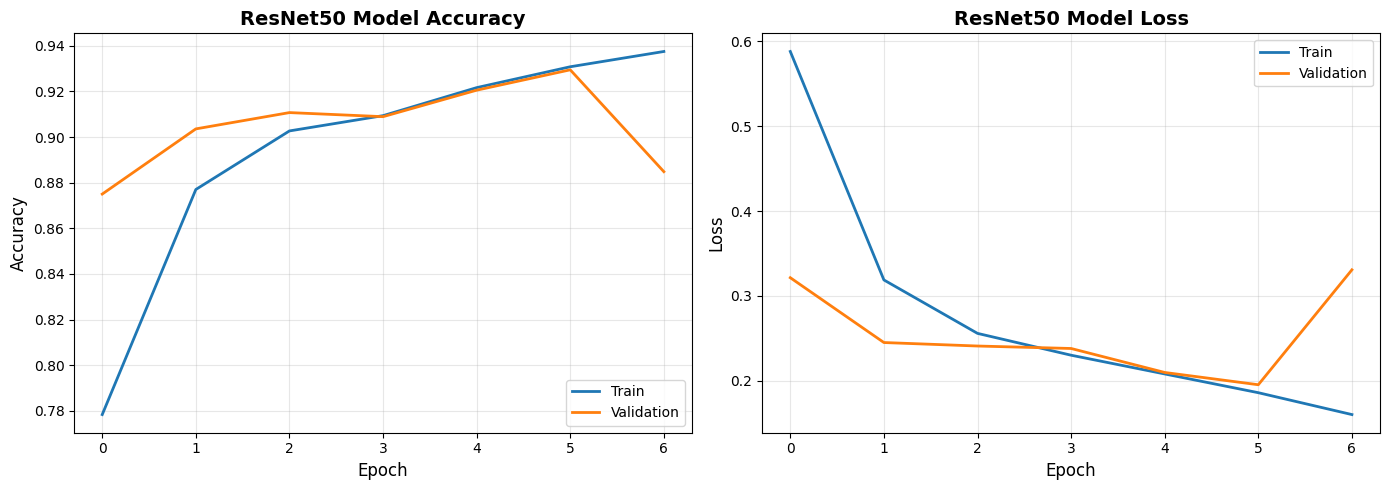

ResNet50 training history saved as 'training_history_resnet.png'


In [40]:
# Plot training history for ResNet50
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_resnet.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history_resnet.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('ResNet50 Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history_resnet.history['loss'], label='Train', linewidth=2)
axes[1].plot(history_resnet.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('ResNet50 Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_resnet.png', dpi=300, bbox_inches='tight')
plt.show()
print("ResNet50 training history saved as 'training_history_resnet.png'")

## 2.14 ResNet50 Model Evaluation on Test Set

In [41]:
print("Evaluating ResNet50 model on test set...")

# Load best model if saved
if os.path.exists(checkpoint_path_resnet):
    resnet_model.load_weights(checkpoint_path_resnet)
    print(f"Loaded best ResNet50 model from {checkpoint_path_resnet}")

# Evaluate on test set
test_results_resnet = resnet_model.evaluate(test_dataset, verbose=0)

# Make predictions
y_test_pred_resnet_prob = resnet_model.predict(test_dataset, verbose=0)
y_test_pred_resnet = np.argmax(y_test_pred_resnet_prob, axis=1)

# Calculate metrics
resnet_accuracy = accuracy_score(y_test, y_test_pred_resnet)
resnet_precision = precision_score(y_test, y_test_pred_resnet, average='weighted')
resnet_recall = recall_score(y_test, y_test_pred_resnet, average='weighted')
resnet_f1 = f1_score(y_test, y_test_pred_resnet, average='weighted')
resnet_confusion = confusion_matrix(y_test, y_test_pred_resnet)

# Print results
print("\n" + "="*50)
print("MODEL 3: ResNet50 End-to-End DL - TEST RESULTS")
print("="*50)
print(f"Accuracy:  {resnet_accuracy:.4f}")
print(f"Precision: {resnet_precision:.4f}")
print(f"Recall:    {resnet_recall:.4f}")
print(f"F1-Score:  {resnet_f1:.4f}")
print(f"Test Loss: {test_results_resnet[0]:.4f}")
print("="*50)

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred_resnet, target_names=CLASSES))

Evaluating ResNet50 model on test set...
Loaded best ResNet50 model from best_model_resnet.h5

MODEL 3: ResNet50 End-to-End DL - TEST RESULTS
Accuracy:  0.8875
Precision: 0.8993
Recall:    0.8875
F1-Score:  0.8855
Test Loss: 0.4517

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.68      0.80       400
  meningioma       0.75      0.91      0.82       400
     notumor       0.94      0.99      0.97       400
   pituitary       0.95      0.97      0.96       400

    accuracy                           0.89      1600
   macro avg       0.90      0.89      0.89      1600
weighted avg       0.90      0.89      0.89      1600



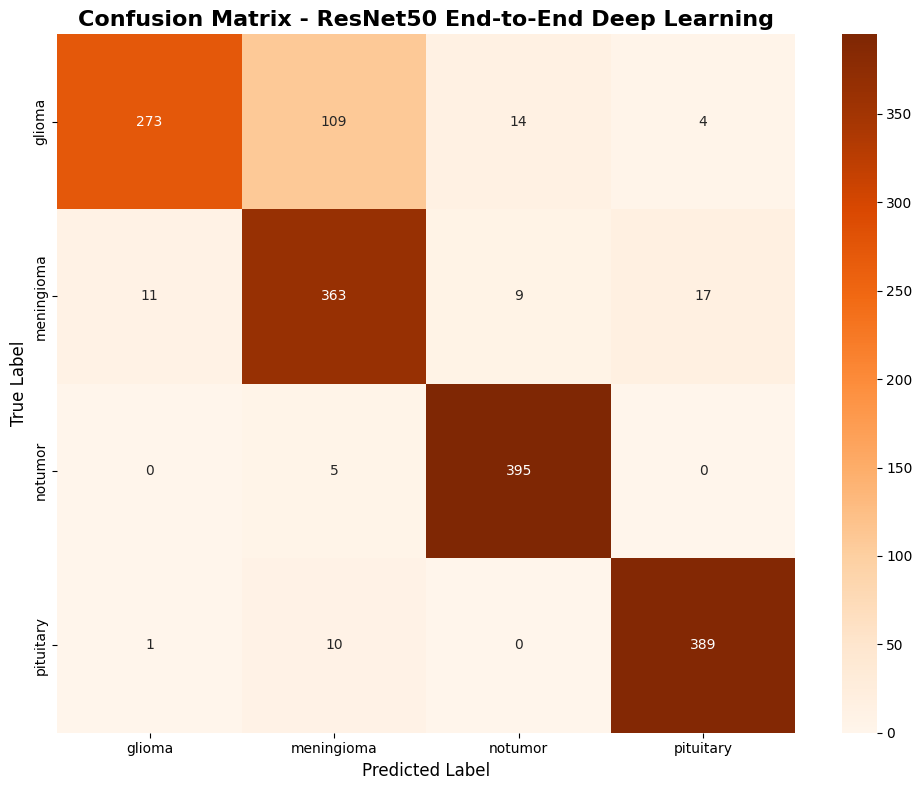

Confusion matrix saved as 'confusion_matrix_resnet.png'


In [42]:
# Plot confusion matrix for ResNet50 model
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    resnet_confusion, 
    annot=True, 
    fmt='d', 
    cmap='Oranges',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=ax
)
ax.set_title('Confusion Matrix - ResNet50 End-to-End Deep Learning', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_resnet.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as 'confusion_matrix_resnet.png'")

In [43]:
# Calculate per-class metrics for ResNet50 model
resnet_per_class_metrics = {}
for idx, class_name in enumerate(CLASSES):
    resnet_per_class_metrics[class_name] = {
        'precision': precision_score(y_test, y_test_pred_resnet, labels=[idx], average='macro'),
        'recall': recall_score(y_test, y_test_pred_resnet, labels=[idx], average='macro'),
        'f1': f1_score(y_test, y_test_pred_resnet, labels=[idx], average='macro')
    }

# Display per-class metrics
resnet_metrics_df = pd.DataFrame(resnet_per_class_metrics).T
print("\nPer-Class Metrics (ResNet50):")
print(resnet_metrics_df.round(4))


Per-Class Metrics (ResNet50):
            precision  recall      f1
glioma         0.9579  0.6825  0.7971
meningioma     0.7454  0.9075  0.8185
notumor        0.9450  0.9875  0.9658
pituitary      0.9488  0.9725  0.9605


---

# MODEL COMPARISON

## 2.10 Comprehensive Model Comparison

In [34]:
# Create comparison table for all three models
comparison_data = {
    'Metric': ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)'],
    'Model 1: EfficientNet-B0 + SVM': [
        f"{svm_accuracy:.4f}",
        f"{svm_precision:.4f}",
        f"{svm_recall:.4f}",
        f"{svm_f1:.4f}"
    ],
    'Model 2: EfficientNet-B0 E2E': [
        f"{e2e_accuracy:.4f}",
        f"{e2e_precision:.4f}",
        f"{e2e_recall:.4f}",
        f"{e2e_f1:.4f}"
    ],
    'Model 3: ResNet50 E2E': [
        f"{resnet_accuracy:.4f}",
        f"{resnet_precision:.4f}",
        f"{resnet_recall:.4f}",
        f"{resnet_f1:.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("COMPREHENSIVE MODEL COMPARISON - TEST SET (3 Models)")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)


COMPREHENSIVE MODEL COMPARISON - TEST SET
              Metric Model 1: EfficientNet-B0 + SVM Model 2: End-to-End DL Difference
            Accuracy                         0.9331                 0.9200    -0.0131
Precision (Weighted)                         0.9390                 0.9239    -0.0151
   Recall (Weighted)                         0.9331                 0.9200    -0.0131
 F1-Score (Weighted)                         0.9318                 0.9183    -0.0134


In [44]:
# Per-class comparison for all three models
per_class_comparison = {}
for class_name in CLASSES:
    per_class_comparison[class_name] = {
        'Model 1: SVM - Precision': f"{svm_per_class_metrics[class_name]['precision']:.4f}",
        'Model 1: SVM - Recall': f"{svm_per_class_metrics[class_name]['recall']:.4f}",
        'Model 1: SVM - F1': f"{svm_per_class_metrics[class_name]['f1']:.4f}",
        'Model 2: E2E - Precision': f"{e2e_per_class_metrics[class_name]['precision']:.4f}",
        'Model 2: E2E - Recall': f"{e2e_per_class_metrics[class_name]['recall']:.4f}",
        'Model 2: E2E - F1': f"{e2e_per_class_metrics[class_name]['f1']:.4f}",
        'Model 3: ResNet - Precision': f"{resnet_per_class_metrics[class_name]['precision']:.4f}",
        'Model 3: ResNet - Recall': f"{resnet_per_class_metrics[class_name]['recall']:.4f}",
        'Model 3: ResNet - F1': f"{resnet_per_class_metrics[class_name]['f1']:.4f}",
    }

per_class_df = pd.DataFrame(per_class_comparison).T
print("\n" + "="*100)
print("PER-CLASS PERFORMANCE COMPARISON (3 Models)")
print("="*100)
print(per_class_df.to_string())
print("="*100)


PER-CLASS PERFORMANCE COMPARISON (3 Models)
           Model 1: SVM - Precision Model 1: SVM - Recall Model 1: SVM - F1 Model 2: E2E - Precision Model 2: E2E - Recall Model 2: E2E - F1 Model 3: ResNet - Precision Model 3: ResNet - Recall Model 3: ResNet - F1
glioma                       0.9810                0.7750            0.8659                   0.9502                0.7625            0.8460                      0.9579                   0.6825               0.7971
meningioma                   0.8373                0.9650            0.8966                   0.8315                0.9375            0.8813                      0.7454                   0.9075               0.8185
notumor                      0.9500                0.9975            0.9732                   0.9412                1.0000            0.9697                      0.9450                   0.9875               0.9658
pituitary                    0.9876                0.9950            0.9913                   0

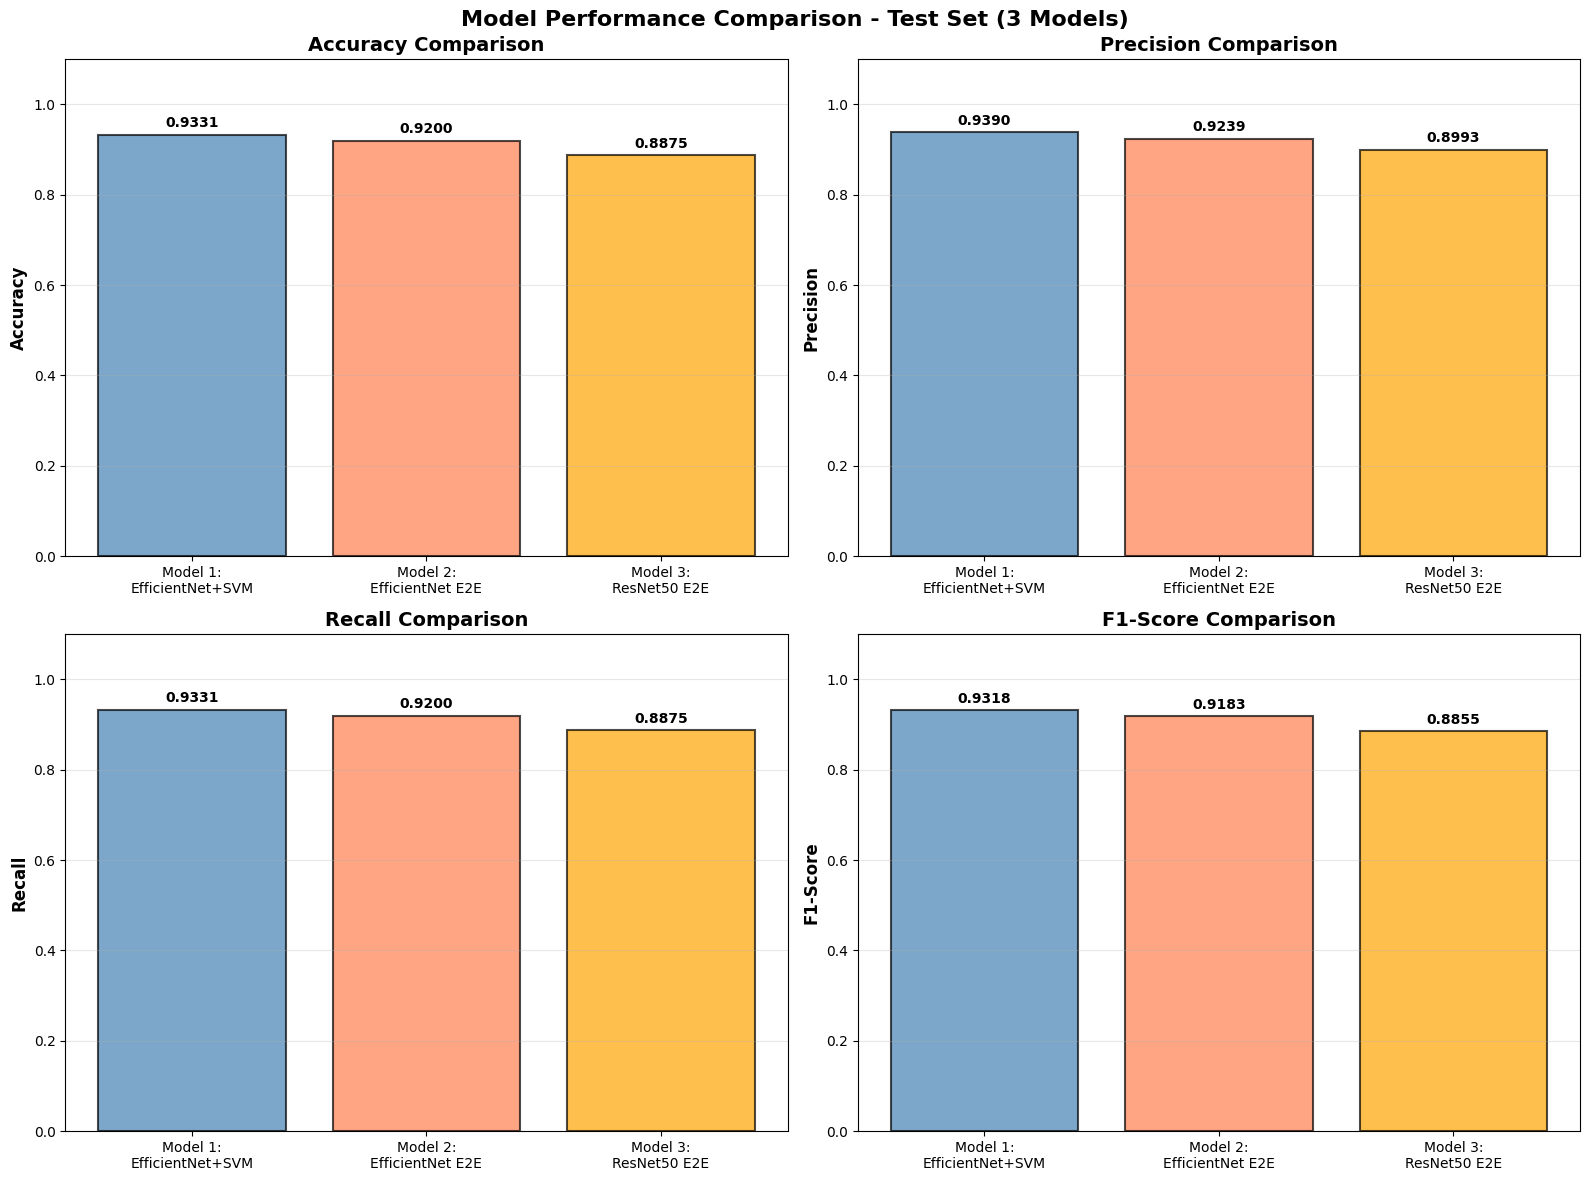

Model comparison chart saved as 'model_comparison_metrics_3models.png'


In [45]:
# Visual comparison of metrics for all three models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
svm_values = [svm_accuracy, svm_precision, svm_recall, svm_f1]
e2e_values = [e2e_accuracy, e2e_precision, e2e_recall, e2e_f1]
resnet_values = [resnet_accuracy, resnet_precision, resnet_recall, resnet_f1]

for idx, (metric, svm_val, e2e_val, resnet_val) in enumerate(zip(metrics, svm_values, e2e_values, resnet_values)):
    ax = axes[idx]
    x = ['Model 1:\nEfficientNet+SVM', 'Model 2:\nEfficientNet E2E', 'Model 3:\nResNet50 E2E']
    y = [svm_val, e2e_val, resnet_val]
    colors = ['steelblue', 'coral', 'orange']
    
    bars = ax.bar(x, y, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, y):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison - Test Set (3 Models)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_metrics_3models.png', dpi=300, bbox_inches='tight')
plt.show()
print("Model comparison chart saved as 'model_comparison_metrics_3models.png'")

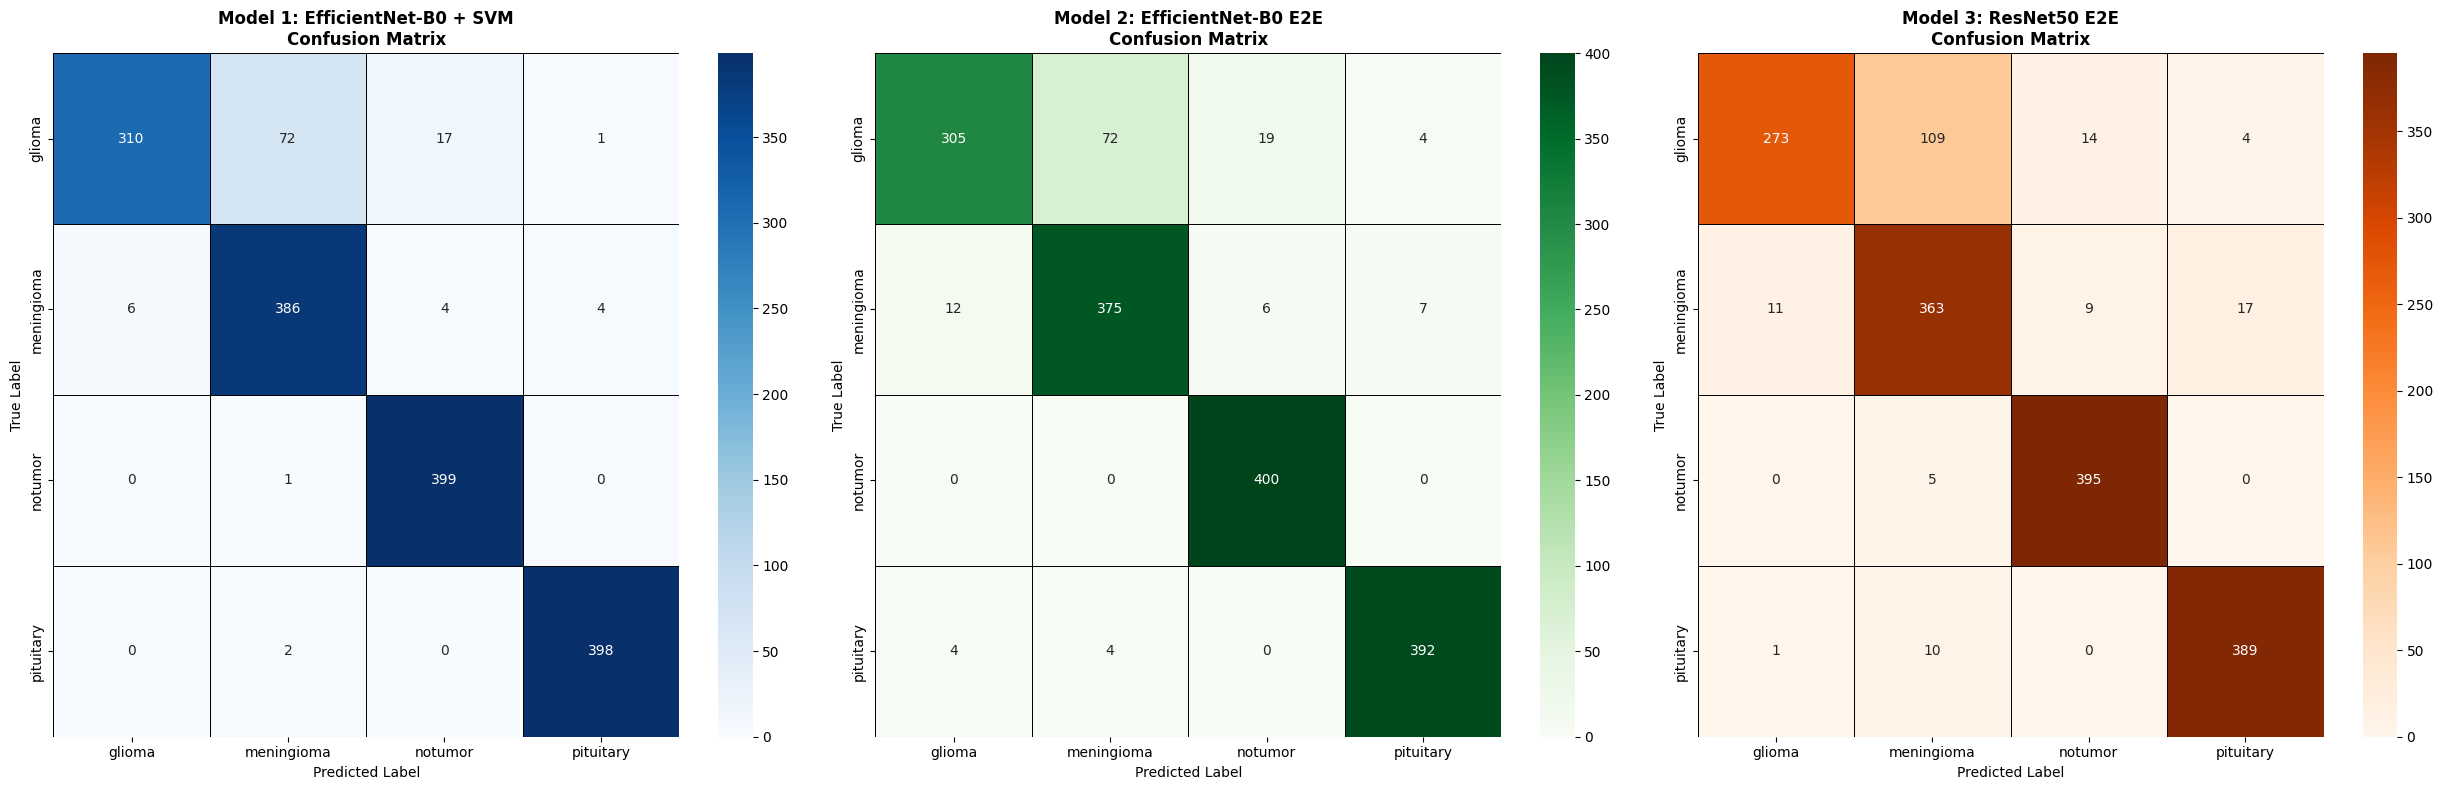

Side-by-side confusion matrices saved as 'confusion_matrices_comparison_3models.png'


In [47]:
# Side-by-side confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(25, 8))

# SVM confusion matrix
sns.heatmap(
    svm_confusion, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=axes[0],
    linewidths=0.5,
    linecolor='black'
)
axes[0].set_title('Model 1: EfficientNet-B0 + SVM\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

# EfficientNet End-to-End confusion matrix
sns.heatmap(
    e2e_confusion, 
    annot=True, 
    fmt='d', 
    cmap='Greens',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=axes[1],
    linewidths=0.5,
    linecolor='black'
)
axes[1].set_title('Model 2: EfficientNet-B0 E2E\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=10)
axes[1].set_ylabel('True Label', fontsize=10)

# ResNet50 confusion matrix
sns.heatmap(
    resnet_confusion, 
    annot=True, 
    fmt='d', 
    cmap='Oranges',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=axes[2],
    linewidths=0.5,
    linecolor='black'
)
axes[2].set_title('Model 3: ResNet50 E2E\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicted Label', fontsize=10)
axes[2].set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices_comparison_3models.png', dpi=300, bbox_inches='tight')
plt.show()
print("Side-by-side confusion matrices saved as 'confusion_matrices_comparison_3models.png'")

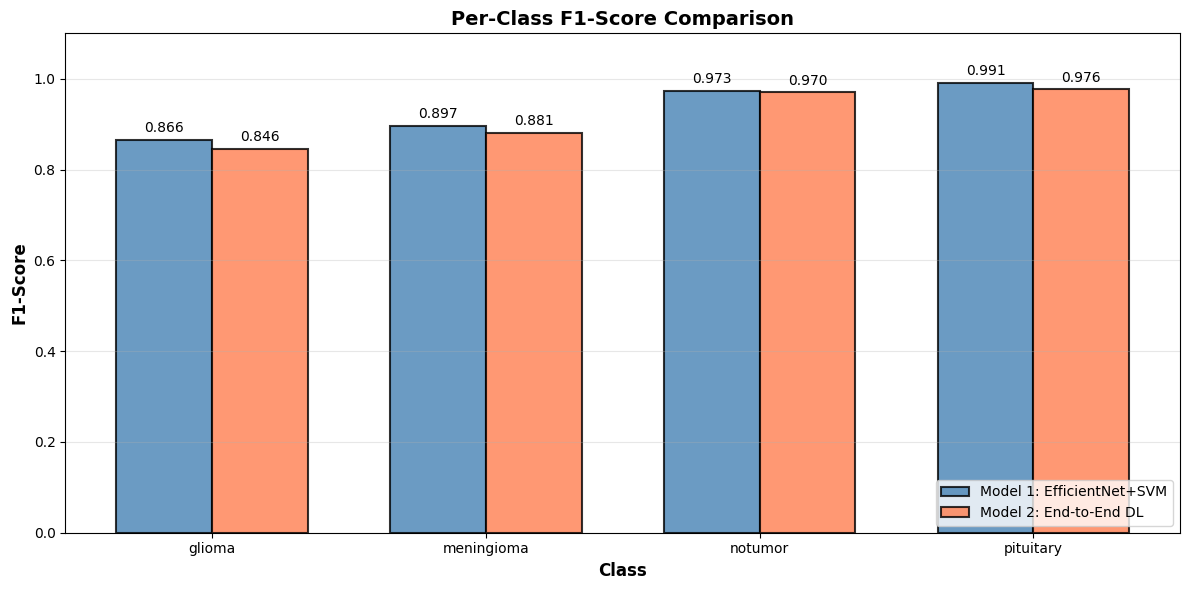

Per-class F1 comparison saved as 'per_class_f1_comparison.png'


In [28]:
# Per-class F1-score comparison for all three models
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(CLASSES))
width = 0.25

svm_f1_per_class = [svm_per_class_metrics[c]['f1'] for c in CLASSES]
e2e_f1_per_class = [e2e_per_class_metrics[c]['f1'] for c in CLASSES]
resnet_f1_per_class = [resnet_per_class_metrics[c]['f1'] for c in CLASSES]

bars1 = ax.bar(x - width, svm_f1_per_class, width, label='Model 1: EfficientNet+SVM', 
                color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, e2e_f1_per_class, width, label='Model 2: EfficientNet E2E', 
                color='coral', alpha=0.8, edgecolor='black', linewidth=1.5)
bars3 = ax.bar(x + width, resnet_f1_per_class, width, label='Model 3: ResNet50 E2E', 
                color='orange', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1-Score Comparison (3 Models)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.legend(loc='lower right')
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('per_class_f1_comparison_3models.png', dpi=300, bbox_inches='tight')
plt.show()
print("Per-class F1 comparison saved as 'per_class_f1_comparison_3models.png'")

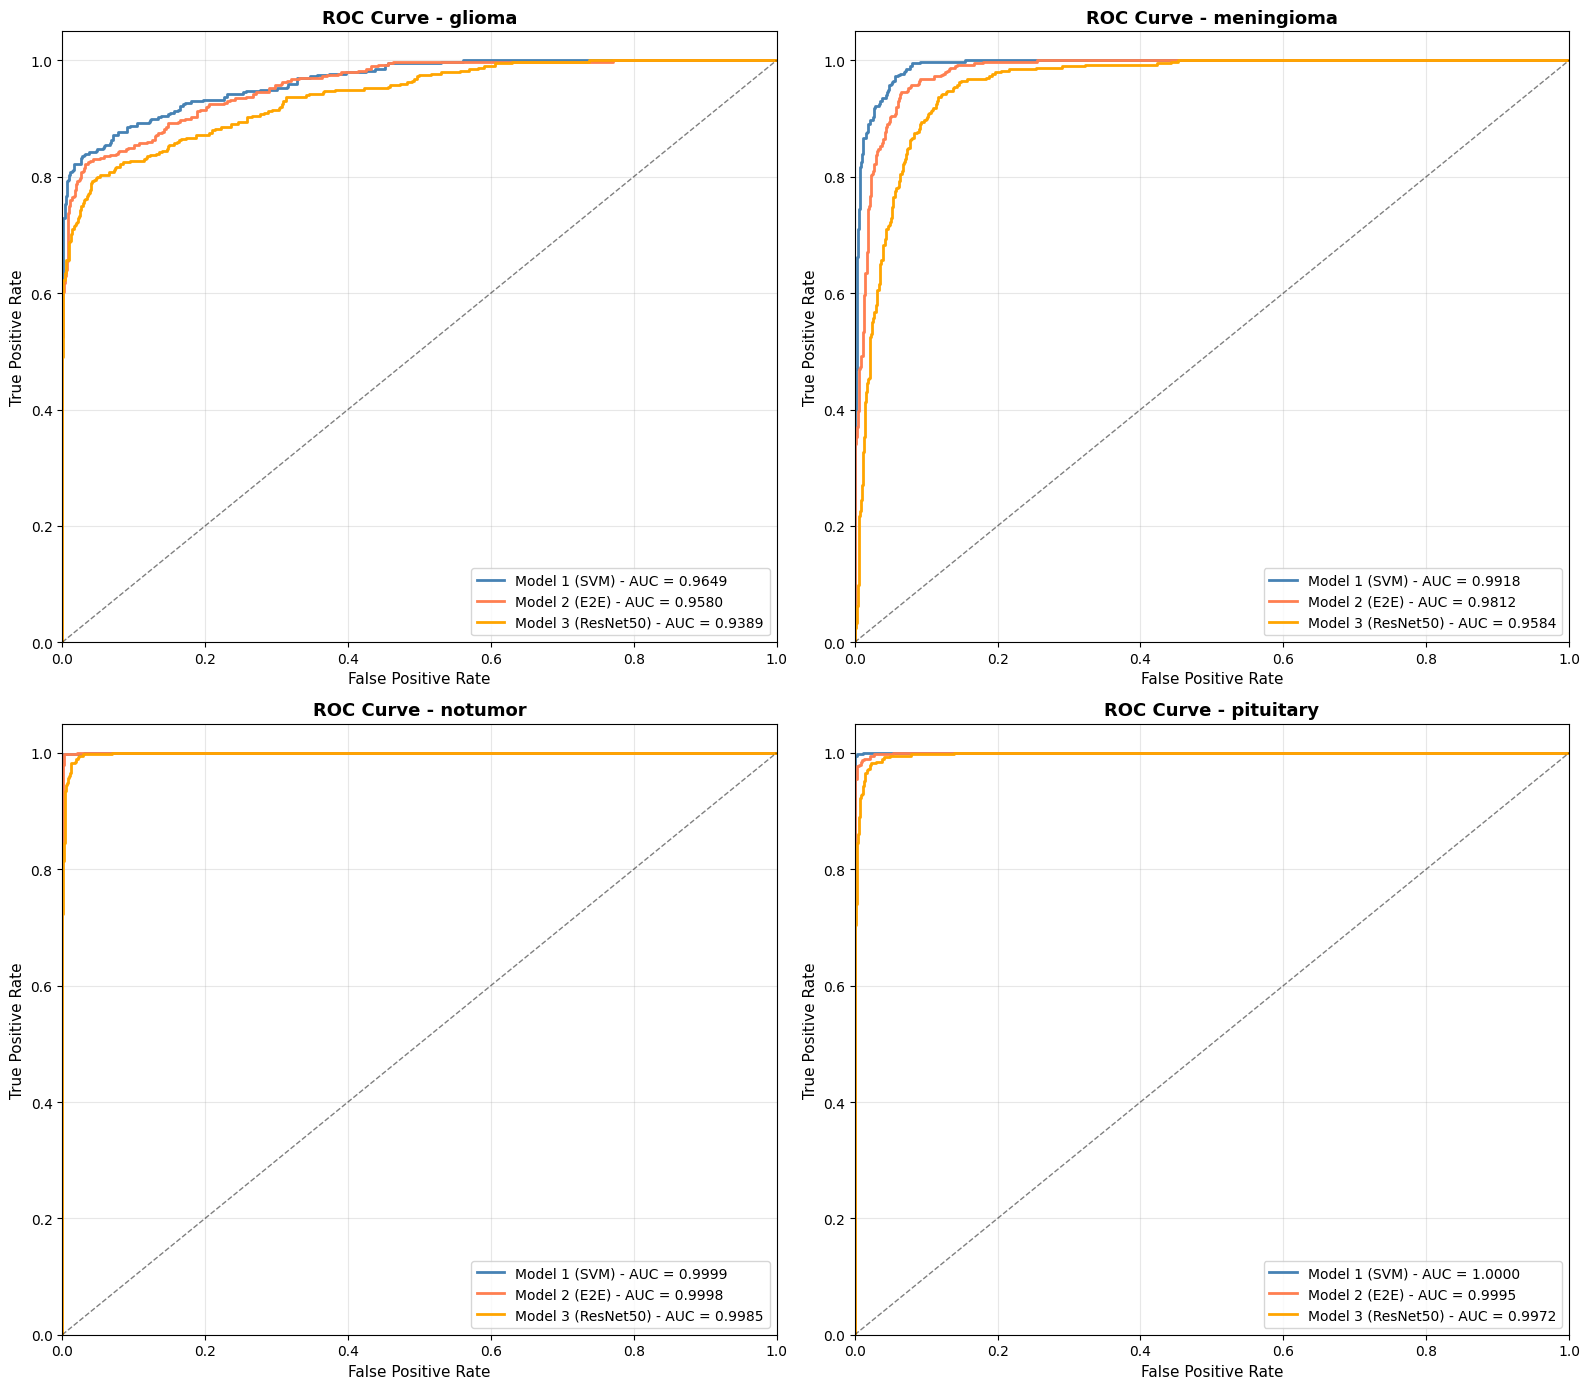

ROC curves saved as 'roc_curves_comparison_3models.png'


In [50]:
# ROC Curve comparison (One-vs-Rest)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels
y_test_bin = label_binarize(y_test, classes=range(NUM_CLASSES))

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, class_name in enumerate(CLASSES):
    ax = axes[idx]
    
    # SVM ROC
    fpr_svm, tpr_svm, _ = roc_curve(y_test_bin[:, idx], y_test_proba_svm[:, idx])
    auc_svm = auc(fpr_svm, tpr_svm)
    ax.plot(fpr_svm, tpr_svm, label=f'Model 1 (SVM) - AUC = {auc_svm:.4f}', 
            linewidth=2, color='steelblue')
    
    # End-to-End ROC
    fpr_e2e, tpr_e2e, _ = roc_curve(y_test_bin[:, idx], y_test_pred_e2e_prob[:, idx])
    auc_e2e = auc(fpr_e2e, tpr_e2e)
    ax.plot(fpr_e2e, tpr_e2e, label=f'Model 2 (E2E) - AUC = {auc_e2e:.4f}', 
            linewidth=2, color='coral')
    
    # ResNet50 ROC
    fpr_resnet, tpr_resnet, _ = roc_curve(y_test_bin[:, idx], y_test_pred_resnet_prob[:, idx])
    auc_resnet = auc(fpr_resnet, tpr_resnet)
    ax.plot(fpr_resnet, tpr_resnet, label=f'Model 3 (ResNet50) - AUC = {auc_resnet:.4f}', 
            linewidth=2, color='orange')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curve - {class_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_comparison_3models.png', dpi=300, bbox_inches='tight')
plt.show()
print("ROC curves saved as 'roc_curves_comparison_3models.png'")

## 2.11 Summary and Analysis

In [53]:
# Create summary report
print("\n" + "="*80)
print("SUMMARY REPORT: BRAIN TUMOR CLASSIFICATION MODEL COMPARISON")
print("="*80)
print(f"\nDate: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Dataset: Brain Tumor MRI Classification")
print(f"Classes: {', '.join(CLASSES)}")
print(f"Test Set Size: {len(y_test)} samples")

print("\n" + "-"*80)
print("MODEL 1: EfficientNet-B0 + SVM (Pre-trained Feature Extractor)")
print("-"*80)
print(f"Accuracy:  {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1-Score:  {svm_f1:.4f}")

print("\n" + "-"*80)
print("MODEL 2: EfficientNet-B0 End-to-End (Frozen Base)")
print("-"*80)
print(f"Accuracy:  {e2e_accuracy:.4f} ({e2e_accuracy*100:.2f}%)")
print(f"Precision: {e2e_precision:.4f}")
print(f"Recall:    {e2e_recall:.4f}")
print(f"F1-Score:  {e2e_f1:.4f}")

print("\n" + "-"*80)
print("MODEL 3: ResNet50 End-to-End (Frozen Base)")
print("-"*80)
print(f"Accuracy:  {resnet_accuracy:.4f} ({resnet_accuracy*100:.2f}%)")
print(f"Precision: {resnet_precision:.4f}")
print(f"Recall:    {resnet_recall:.4f}")
print(f"F1-Score:  {resnet_f1:.4f}")

print("\n" + "-"*80)
print("PERFORMANCE COMPARISON")
print("-"*80)
print("Model 1 vs Model 2:")
print(f"Accuracy:  {(e2e_accuracy - svm_accuracy)*100:+.2f} percentage points")
print(f"Precision: {(e2e_precision - svm_precision)*100:+.2f} percentage points")
print(f"Recall:    {(e2e_recall - svm_recall)*100:+.2f} percentage points")
print(f"F1-Score:  {(e2e_f1 - svm_f1)*100:+.2f} percentage points")

print("\nModel 2 vs Model 3:")
print(f"Accuracy:  {(resnet_accuracy - e2e_accuracy)*100:+.2f} percentage points")
print(f"Precision: {(resnet_precision - e2e_precision)*100:+.2f} percentage points")
print(f"Recall:    {(resnet_recall - e2e_recall)*100:+.2f} percentage points")
print(f"F1-Score:  {(resnet_f1 - e2e_f1)*100:+.2f} percentage points")

print("\nModel 1 vs Model 3:")
print(f"Accuracy:  {(resnet_accuracy - svm_accuracy)*100:+.2f} percentage points")
print(f"Precision: {(resnet_precision - svm_precision)*100:+.2f} percentage points")
print(f"Recall:    {(resnet_recall - svm_recall)*100:+.2f} percentage points")
print(f"F1-Score:  {(resnet_f1 - svm_f1)*100:+.2f} percentage points")

print("\n" + "-"*80)
print("COMPUTATIONAL COMPARISON")
print("-"*80)
print("Model 1 (EfficientNet-B0 + SVM):")
print("  - Feature extraction: One-time forward pass through frozen CNN")
print("  - Training time: Fast (SVM converges quickly)")
print("  - Inference: Fast (CNN forward pass + SVM prediction)")
print("  - Memory: Low (only SVM parameters need to be stored)")

print("\nModel 2 (EfficientNet-B0 End-to-End):")
print("  - Training: Simple training (frozen base model)")
print("  - Training time: Moderate (backpropagation through classifier head only)")
print("  - Inference: Single forward pass through entire model")
print("  - Memory: Moderate (entire model parameters)")

print("\nModel 3 (ResNet50 End-to-End):")
print("  - Training: Simple training (frozen base model)")
print("  - Training time: Moderate (backpropagation through classifier head only)")
print("  - Inference: Single forward pass through entire model")
print("  - Memory: Higher (larger ResNet50 model parameters)")
print("  - Memory: Moderate (classifier head + frozen base model)")

print("\n" + "-"*80)
print("KEY FINDINGS")
print("-"*80)
if e2e_accuracy > svm_accuracy:
    print(f"✓ Model 2 (End-to-End) achieved higher accuracy: +{(e2e_accuracy - svm_accuracy)*100:.2f}%")
else:
    print(f"✗ Model 1 (SVM) achieved higher accuracy: +{(svm_accuracy - e2e_accuracy)*100:.2f}%")

best_class_svm = max(svm_per_class_metrics.items(), key=lambda x: x[1]['f1'])
worst_class_svm = min(svm_per_class_metrics.items(), key=lambda x: x[1]['f1'])
print(f"\nSVM Best Class: {best_class_svm[0]} (F1: {best_class_svm[1]['f1']:.4f})")
print(f"SVM Worst Class: {worst_class_svm[0]} (F1: {worst_class_svm[1]['f1']:.4f})")

best_class_e2e = max(e2e_per_class_metrics.items(), key=lambda x: x[1]['f1'])
worst_class_e2e = min(e2e_per_class_metrics.items(), key=lambda x: x[1]['f1'])
print(f"\nEnd-to-End Best Class: {best_class_e2e[0]} (F1: {best_class_e2e[1]['f1']:.4f})")
print(f"End-to-End Worst Class: {worst_class_e2e[0]} (F1: {worst_class_e2e[1]['f1']:.4f})")

print("\n" + "="*80)
print("Generated Visualizations:")
print("="*80)
print("  - confusion_matrix_svm.png")
print("  - confusion_matrix_e2e.png")
print("  - confusion_matrices_comparison.png")
print("  - training_history_e2e.png")
print("  - model_comparison_metrics.png")
print("  - per_class_f1_comparison.png")
print("  - roc_curves_comparison.png")
print("  - best_model_e2e.h5 (saved model weights)")

print("\n" + "="*80)
print("END OF REPORT")
print("="*80 + "\n")


SUMMARY REPORT: BRAIN TUMOR CLASSIFICATION MODEL COMPARISON

Date: 2026-05-14 02:41:27
Dataset: Brain Tumor MRI Classification
Classes: glioma, meningioma, notumor, pituitary
Test Set Size: 1600 samples

--------------------------------------------------------------------------------
MODEL 1: EfficientNet-B0 + SVM (Pre-trained Feature Extractor)
--------------------------------------------------------------------------------
Accuracy:  0.9331 (93.31%)
Precision: 0.9390
Recall:    0.9331
F1-Score:  0.9318

--------------------------------------------------------------------------------
MODEL 2: EfficientNet-B0 End-to-End (Frozen Base)
--------------------------------------------------------------------------------
Accuracy:  0.9200 (92.00%)
Precision: 0.9239
Recall:    0.9200
F1-Score:  0.9183

--------------------------------------------------------------------------------
MODEL 3: ResNet50 End-to-End (Frozen Base)
----------------------------------------------------------------------

## 2.12 Export Results to JSON

In [52]:
# Export results to JSON for documentation
results_export = {
    'timestamp': datetime.now().isoformat(),
    'model_1_svm': {
        'accuracy': svm_accuracy,
        'precision': svm_precision,
        'recall': svm_recall,
        'f1_score': svm_f1,
        'confusion_matrix': svm_confusion.tolist()
    },
    'model_2_e2e': {
        'accuracy': e2e_accuracy,
        'precision': e2e_precision,
        'recall': e2e_recall,
        'f1_score': e2e_f1,
        'confusion_matrix': e2e_confusion.tolist()
    },
    'model_3_resnet': {
        'accuracy': resnet_accuracy,
        'precision': resnet_precision,
        'recall': resnet_recall,
        'f1_score': resnet_f1,
        'confusion_matrix': resnet_confusion.tolist()
    },
    'per_class_metrics': {
        'svm': svm_per_class_metrics,
        'e2e': e2e_per_class_metrics,
        'resnet': resnet_per_class_metrics
    }
}

with open('model_comparison_results.json', 'w') as f:
    json.dump(results_export, f, indent=2)

print("Results exported to 'model_comparison_results.json'")

Results exported to 'model_comparison_results.json'


## 2.13 Save Models for Future Use

In [32]:
import joblib

# Save SVM model
joblib.dump(svm_model, 'svm_brain_tumor_classifier.pkl')
print("SVM model saved as 'svm_brain_tumor_classifier.pkl'")

# Save scaler
joblib.dump(scaler, 'feature_scaler.pkl')
print("Feature scaler saved as 'feature_scaler.pkl'")

# Save end-to-end EfficientNet model
e2e_model.save('end_to_end_brain_tumor_model.h5')
print("End-to-end model saved as 'end_to_end_brain_tumor_model.h5'")

# Save ResNet50 model
resnet_model.save('resnet50_brain_tumor_model.h5')
print("ResNet50 model saved as 'resnet50_brain_tumor_model.h5'")

SVM model saved as 'svm_brain_tumor_classifier.pkl'
Feature scaler saved as 'feature_scaler.pkl'
End-to-end model saved as 'end_to_end_brain_tumor_model.h5'


---

## 2.15 Combined Learning Curves: Model 2 vs. Model 3

Side-by-side comparison of training and validation accuracy/loss curves to analyze convergence behavior across the two end-to-end models.

In [ ]:
# Combined Learning Curves: Model 2 (EfficientNet E2E) vs Model 3 (ResNet50 E2E)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Learning Curves: EfficientNet-B0 E2E vs ResNet50 E2E',
             fontsize=14, fontweight='bold')

c_e2e = {'train': '#1565C0', 'val': '#C62828'}
c_resnet = {'train': '#2E7D32', 'val': '#E65100'}

epochs_e2e = range(1, len(history_e2e.history['accuracy']) + 1)
epochs_resnet = range(1, len(history_resnet.history['accuracy']) + 1)

# Model 2 - Accuracy
axes[0, 0].plot(epochs_e2e, history_e2e.history['accuracy'],
                color=c_e2e['train'], linewidth=2.5, marker='o', markersize=5, label='Train')
axes[0, 0].plot(epochs_e2e, history_e2e.history['val_accuracy'],
                color=c_e2e['val'], linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Validation')
axes[0, 0].set_title('Model 2: EfficientNet-B0 E2E — Accuracy', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0.7, 1.0])

# Model 3 - Accuracy
axes[0, 1].plot(epochs_resnet, history_resnet.history['accuracy'],
                color=c_resnet['train'], linewidth=2.5, marker='o', markersize=5, label='Train')
axes[0, 1].plot(epochs_resnet, history_resnet.history['val_accuracy'],
                color=c_resnet['val'], linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Validation')
axes[0, 1].set_title('Model 3: ResNet50 E2E — Accuracy', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.7, 1.0])

# Model 2 - Loss
axes[1, 0].plot(epochs_e2e, history_e2e.history['loss'],
                color=c_e2e['train'], linewidth=2.5, marker='o', markersize=5, label='Train')
axes[1, 0].plot(epochs_e2e, history_e2e.history['val_loss'],
                color=c_e2e['val'], linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Validation')
axes[1, 0].set_title('Model 2: EfficientNet-B0 E2E — Loss', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Model 3 - Loss
axes[1, 1].plot(epochs_resnet, history_resnet.history['loss'],
                color=c_resnet['train'], linewidth=2.5, marker='o', markersize=5, label='Train')
axes[1, 1].plot(epochs_resnet, history_resnet.history['val_loss'],
                color=c_resnet['val'], linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Validation')
axes[1, 1].set_title('Model 3: ResNet50 E2E — Loss', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('combined_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Combined learning curves saved as combined_learning_curves.png')

## 2.16 Performance Dashboard

Comprehensive side-by-side visualization of all metrics and per-class F1-scores for all three models.

In [ ]:
# Performance Dashboard - All Three Models
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

model_names_short = ['M1: EfficientNet\n+SVM', 'M2: EfficientNet\nE2E', 'M3: ResNet50\nE2E']
model_colors = ['#1565C0', '#2E7D32', '#E65100']

accuracies = [svm_accuracy, e2e_accuracy, resnet_accuracy]
precisions = [svm_precision, e2e_precision, resnet_precision]
recalls    = [svm_recall, e2e_recall, resnet_recall]
f1s        = [svm_f1, e2e_f1, resnet_f1]

# Plot 1: Accuracy
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar(model_names_short, [a*100 for a in accuracies], color=model_colors,
                edgecolor='black', linewidth=0.7, width=0.5)
ax1.set_title('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_ylim([82, 97])
ax1.set_ylabel('Accuracy (%)')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             f'{val*100:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: F1-Score
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(model_names_short, [f*100 for f in f1s], color=model_colors,
                edgecolor='black', linewidth=0.7, width=0.5)
ax2.set_title('Weighted F1-Score (%)', fontsize=12, fontweight='bold')
ax2.set_ylim([82, 97])
ax2.set_ylabel('F1-Score (%)')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             f'{val*100:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: All metrics grouped
ax3 = fig.add_subplot(gs[0, 2])
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
x3 = np.arange(len(metric_labels))
w3 = 0.25
all_m = [[svm_accuracy, svm_precision, svm_recall, svm_f1],
         [e2e_accuracy, e2e_precision, e2e_recall, e2e_f1],
         [resnet_accuracy, resnet_precision, resnet_recall, resnet_f1]]
short_labels = ['M1:SVM', 'M2:E2E', 'M3:ResNet']
for i, (metrics, color, lbl) in enumerate(zip(all_m, model_colors, short_labels)):
    ax3.bar(x3 + (i - 1)*w3, [m*100 for m in metrics], w3,
            label=lbl, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
ax3.set_title('All Metrics Overview', fontsize=12, fontweight='bold')
ax3.set_xticks(x3)
ax3.set_xticklabels(metric_labels, fontsize=10)
ax3.set_ylim([82, 97])
ax3.set_ylabel('Score (%)')
ax3.legend(fontsize=8, loc='lower right')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Per-class F1 comparison (bottom full row)
ax4 = fig.add_subplot(gs[1, :])
class_names_display = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
svm_f1_pc   = [svm_per_class_metrics[c]['f1'] for c in CLASSES]
e2e_f1_pc   = [e2e_per_class_metrics[c]['f1'] for c in CLASSES]
resnet_f1_pc = [resnet_per_class_metrics[c]['f1'] for c in CLASSES]

x4 = np.arange(len(class_names_display))
w4 = 0.25
b1 = ax4.bar(x4 - w4, svm_f1_pc, w4, label='Model 1: EfficientNet+SVM',
             color='#1565C0', edgecolor='black', linewidth=0.5)
b2 = ax4.bar(x4,      e2e_f1_pc, w4, label='Model 2: EfficientNet E2E',
             color='#2E7D32', edgecolor='black', linewidth=0.5)
b3 = ax4.bar(x4 + w4, resnet_f1_pc, w4, label='Model 3: ResNet50 E2E',
             color='#E65100', edgecolor='black', linewidth=0.5)
ax4.set_title('Per-Class F1-Score Comparison Across All Three Models',
              fontsize=12, fontweight='bold')
ax4.set_xticks(x4)
ax4.set_xticklabels(class_names_display, fontsize=12)
ax4.set_ylabel('F1-Score')
ax4.set_ylim([0.70, 1.05])
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)
for group_bars in [b1, b2, b3]:
    for bar in group_bars:
        h = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                 f'{h:.3f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Brain Tumor Classification - Performance Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('performance_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print('Performance dashboard saved as performance_dashboard.png')

---

# CONCLUSION

## Step 2 Completion Summary

This notebook now compares three brain tumor classifiers:
- Model 1: EfficientNet-B0 + SVM
- Model 2: EfficientNet-B0 end-to-end (frozen base)
- Model 3: ResNet50 end-to-end (frozen base)

### Key outcomes
- Implemented feature extraction, SVM classification, and two frozen-base transfer learning models
- Added evaluation on accuracy, precision, recall, F1-score, and confusion matrices
- Included model export to JSON and saved model artifacts for future use

### Generated outputs
- `model_comparison_results.json`
- `svm_brain_tumor_classifier.pkl`
- `feature_scaler.pkl`
- `end_to_end_brain_tumor_model.h5`
- `resnet50_brain_tumor_model.h5`

---

**Notebook ready for review.**